In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path_2012 = r"H:\PYTHON\3_ETAPA\atividade_6\Tabela5-sem_emprego_2012.csv"
path_2026 = r"H:\PYTHON\3_ETAPA\atividade_6\Tabela5-sem_emprego_2026.csv"
path_horas = r"H:\PYTHON\3_ETAPA\atividade_6\Tabela 1.1.1.xls"

In [4]:
tab_2012 =pd.read_csv(path_2012, encoding="utf8", sep = ";", decimal = ",")

In [5]:
tab_2012

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1)
0,AC,12,Acre,45.3,54.7
1,AL,27,Alagoas,44.7,55.3
2,AM,13,Amazonas,47.5,52.5
3,AP,16,Amapá,48.1,51.9
4,BA,29,Bahia,43.8,56.2
5,CE,23,Ceará,51.1,48.9
6,DF,53,Distrito Federal,41.0,59.0
7,ES,32,Espírito Santo,46.4,53.6
8,GO,52,Goiás,41.0,59.0
9,MA,21,Maranhão,47.2,52.8


In [7]:
tab_2026 = pd.read_csv(path_2026, encoding="utf8", sep =";", decimal=",")
tab_2026 

,Sigla,Código,Estado,Desocupados - homens (2026 T1),Desocupados - mulheres (2026 T1)
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [10]:
tab_2026 = tab_2026.rename(columns= {"Desocupados - homens (2026 T1)": "homens_2026"})

In [11]:
tab_2026 = tab_2026.rename(columns= {"Desocupados - mulheres (2026 T1)": "mulheres_2026"})

In [12]:
tab_2026

,Sigla,Código,Estado,homens_2026,mulheres_2026
0,AC,12,Acre,53.2,46.8
1,AL,27,Alagoas,50.7,49.3
2,AM,13,Amazonas,46.8,53.2
3,AP,16,Amapá,51.1,48.9
4,BA,29,Bahia,44.7,55.3
5,CE,23,Ceará,52.7,47.3
6,DF,53,Distrito Federal,47.9,52.1
7,ES,32,Espírito Santo,47.5,52.5
8,GO,52,Goiás,47.5,52.5
9,MA,21,Maranhão,49.1,50.9


In [15]:
comp = tab_2012.merge(tab_2026, on =  ["Sigla", "Código", "Estado"], how = "inner")
comp

,Sigla,Código,Estado,Desocupados - homens (2012 T1),Desocupados - mulheres (2012 T1),homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


In [16]:
indicador_1 = pd.read_excel(path_horas, engine='xlrd')

In [17]:
# Linhas 0-7: título/cabeçalho | 8-40: resultados | 41+: fonte e notas
indicador_1 = indicador_1.iloc[8:41].copy()
indicador_1.columns = [
    "uf_regiao",
    "total",
    "total_branca",
    "total_preta_parda",
    "homem_branca",
    "homem_preta_parda",
    "mulher_branca",
    "mulher_preta_parda",
]
indicador_1 = indicador_1.reset_index(drop=True)


In [18]:
regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]

estados = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]


In [19]:
indicador_1


,uf_regiao,total,total_branca,total_preta_parda,homem_branca,homem_preta_parda,mulher_branca,mulher_preta_parda
0,Norte,16.187037,15.925246,16.256032,11.588653,11.514646,19.29578,20.534188
1,Rondônia,17.014162,16.727733,17.101523,12.111127,12.54408,20.412887,21.06141
2,Acre,13.606903,13.806929,13.541399,10.79612,9.686983,16.130352,16.710754
3,Amazonas,16.80729,15.987545,16.995493,12.233043,12.822584,18.764969,20.716986
4,Roraima,13.639257,13.651755,13.633606,10.814803,10.476601,16.135877,16.560244
5,Pará,16.474268,16.181627,16.560239,11.524306,11.026707,19.83511,21.591144
6,Amapá,13.586656,14.38918,13.415091,11.116821,10.749444,16.648579,15.908487
7,Tocantins,15.815781,15.701788,15.768728,10.733863,11.682616,19.663713,19.629399
8,Nordeste,18.499396,18.1517,18.610911,11.723907,11.848436,22.744666,23.716716
9,Maranhão,16.669614,16.421773,16.708894,11.665173,11.437359,19.881056,20.739589


In [21]:
estados = estados.rename(columns={"uf_regiao": "Estado"})


In [22]:
comp = comp.merge(estados, on = "Estado", how = "inner")


In [23]:
t2012 = pd.read_csv(path_2012, sep=";", decimal=",", encoding="utf-8-sig")


Text(0.5, 1.0, 'Desocupação: participação feminina em 2012 T1 e 2026 T1')

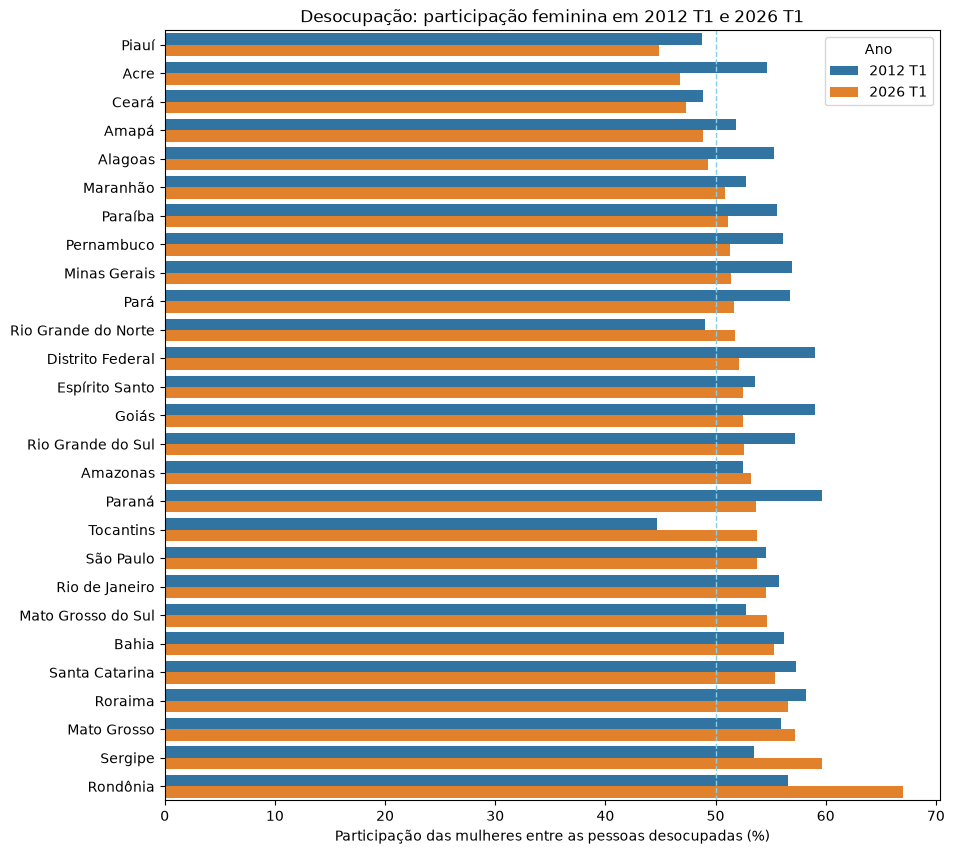

In [26]:
ordem = comp.sort_values("mulheres_2026")["Estado"]
longo = comp.melt(
    id_vars=["Estado"],
    value_vars=["Desocupados - mulheres (2012 T1)", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"Desocupados - mulheres (2012 T1)": "2012 T1", "mulheres_2026": "2026 T1"})

fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)

ax.axvline(50, color="skyblue", linestyle="--", linewidth=1) # MUDE A COR
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
